# AI-Based Ecological Predictive Cruise Control for Connected EVs

**Riyan Wankhede (23BCE9287), Nishita (23BCE8235)** · VIT-AP University

An EV follows a reference speed (the traffic ahead). A stacked LSTM forecasts that reference speed 2 s ahead from its
last 10 s, and two predictive controllers use the forecast: a PID with deceleration feedforward (**LSTM-PID**) and a
receding-horizon optimiser (**LSTM-MPC**). They are compared with a bang-bang controller and a plain PID, and every
forecast is bracketed by two references: *persistence* (the speed stays where it is, i.e. no forecast) and an *oracle*
(the true future speed, a perfect V2X preview).

* **Test profiles:** the EPA UDDS (city), HWFET (highway) and US06 (aggressive) drive cycles, never used for training
  or tuning.
* **LSTM training data:** synthetic traffic speed episodes in three driving styles, split by episode.
* **Vehicle:** 2.5 t EV with a 9:1 reduction gear, motor torque and power limits, speed-dependent regen and friction brakes.
* **Metrics:** net battery energy per km, speed-tracking RMSE, RMS jerk.

The simulator (vehicle, controllers, metrics, LSTM data and training) lives in [`eco_py`](eco_py) so the controller runs can execute in
parallel. Runtime: about 15 minutes on a laptop CPU (LSTM training about 5 minutes; the simulations run on up to 8 cores).

In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42          # multi_seed_evaluation.ipynb repeats the LSTM part with 5 seeds

## 0. Simulator

The definitions every later cell uses: drive-cycle loading, the EV plant, the forecasts, the LSTM data and training,
the controllers, and the simulation / metrics / parallel runner. Each cell starts with `# ── Definitions:` so
`multi_seed_evaluation.ipynb` can replay exactly these cells.

In [2]:
# ── Definitions: drive cycles ────────────────────────────────────────────────────────────────────
import os
import numpy as np
from scipy.optimize import minimize
from joblib import Parallel, delayed

DT = 0.1    # simulation step (s)
H = 20      # forecast horizon (steps) = 2 s


def load_cycle(path):
    """EPA drive schedule (tab-separated seconds / mph) -> reference speed in m/s at DT spacing."""
    rows = []
    for line in open(path, encoding="utf-8"):
        parts = line.strip().split("\t")
        try:
            rows.append((float(parts[0]), float(parts[1])))
        except (ValueError, IndexError):
            continue                                   # header lines
    t, mph = np.array(rows).T
    t_fine = np.arange(0, t[-1] + 1e-9, DT)
    return np.interp(t_fine, t, mph * 0.44704)

In [3]:
# ── Definitions: EV plant ────────────────────────────────────────────────────────────────────────
class ElectricVehicle:
    """Longitudinal EV model with a single-speed reduction gear, motor torque and power limits,
    speed-dependent regenerative braking and friction brakes for the rest."""

    def __init__(self, mass=2500, frontal_area=2.5, drag_coeff=0.28, rolling_coeff=0.015,
                 wheel_radius=0.36, gear_ratio=9.0, motor_max_torque=400, motor_max_power=150e3,
                 regen_max_torque=200, regen_max_power=60e3, motor_eff=0.92, regen_eff=0.75,
                 friction_brake_max=8000):
        self.mass, self.frontal_area, self.drag_coeff = mass, frontal_area, drag_coeff
        self.rolling_coeff, self.wheel_radius, self.gear_ratio = rolling_coeff, wheel_radius, gear_ratio
        self.motor_max_torque, self.motor_max_power = motor_max_torque, motor_max_power
        self.regen_max_torque, self.regen_max_power = regen_max_torque, regen_max_power
        self.motor_eff, self.regen_eff, self.friction_brake_max = motor_eff, regen_eff, friction_brake_max
        self.rho = 1.206
        self.reset()

    def reset(self, v0=0.0):
        self.v = v0
        self.energy_wh = 0.0      # net battery energy: motoring minus recovered regen
        self.regen_wh = 0.0
        self.friction_wh = 0.0    # kinetic energy lost in the friction brakes
        self.dist = 0.0

    def limits(self, v):
        """Wheel-torque limits (Nm) at speed v: (max drive, max regen)."""
        om = max(v, 1e-3) / self.wheel_radius * self.gear_ratio            # motor speed (rad/s)
        drive = min(self.motor_max_torque, self.motor_max_power / om) * self.gear_ratio
        regen = min(self.regen_max_torque, self.regen_max_power / om) * self.gear_ratio if v > 1.0 else 0.0
        return drive, regen

    def step(self, t_cmd, dt=DT):
        """Apply a wheel-torque command (Nm, negative = braking) for one step; returns the applied torque."""
        v = self.v
        drive, regen = self.limits(v)
        T = min(max(t_cmd, -self.friction_brake_max - regen), drive)
        om = v / self.wheel_radius * self.gear_ratio
        if T >= 0:
            p_batt = (T / self.gear_ratio) * om / self.motor_eff
        else:
            t_reg = max(T, -regen)                     # regen first, friction brakes for the rest
            p_batt = (t_reg / self.gear_ratio) * om * self.regen_eff
            self.regen_wh -= p_batt * dt / 3600
            self.friction_wh += -(T - t_reg) / self.wheel_radius * v * dt / 3600
        f = T / self.wheel_radius - 0.5 * self.drag_coeff * self.frontal_area * self.rho * v * v \
            - (self.mass * 9.81 * self.rolling_coeff if v > 0.01 else 0.0)
        self.v = max(0.0, v + f / self.mass * dt)
        self.energy_wh += p_batt * dt / 3600
        self.dist += self.v * dt
        return T

In [4]:
# ── Definitions: forecasts of the reference speed ────────────────────────────────────────────────
def forecast_oracle(ref):
    """The true next H reference speeds (perfect V2X preview): an upper bound for any predictor."""
    pad = np.concatenate([ref, np.full(H, ref[-1])])
    return np.stack([pad[k + 1:k + 1 + H] for k in range(len(ref))])


def forecast_persistence(ref):
    """'Speed stays where it is now': the no-information baseline."""
    return np.repeat(ref[:, None], H, axis=1)


def forecast_const_accel(ref, lookback=10):
    """Extrapolate the last second's acceleration, clipped at zero speed."""
    past = np.concatenate([np.full(lookback, ref[0]), ref])[:len(ref)]
    slope = (ref - past) / (lookback * DT)
    steps = np.arange(1, H + 1) * DT
    return np.maximum(ref[:, None] + slope[:, None] * steps[None, :], 0.0)


def history_windows(ref, seq_len=100):
    """Past seq_len reference speeds ending at each step (left-padded with the first value)."""
    pad = np.concatenate([np.full(seq_len - 1, ref[0]), ref])
    return np.lib.stride_tricks.sliding_window_view(pad, seq_len)

In [5]:
# ── Definitions: LSTM forecaster ─────────────────────────────────────────────────────────────────
SEQ = 100   # LSTM input: last 100 steps = 10 s of reference speed

STYLES = {  # uniform ranges: cruise speed (m/s), P(stop), accel and decel (m/s²), cruise and idle time (s)
    "urban":      dict(v=(4, 17),  stop=0.55, acc=(0.4, 1.5), dec=(0.5, 1.6), hold=(3, 30), idle=(3, 25)),
    "highway":    dict(v=(18, 33), stop=0.05, acc=(0.2, 1.0), dec=(0.2, 1.2), hold=(10, 70), idle=(3, 10)),
    "aggressive": dict(v=(8, 36),  stop=0.30, acc=(1.0, 3.5), dec=(1.0, 3.0), hold=(2, 20), idle=(2, 10)),
}


def synthetic_episode(rng, style, T=300.0):
    """One synthetic traffic-speed episode: accelerate -> cruise (slow wobble) -> decelerate or stop -> idle, repeated."""
    from scipy.ndimage import gaussian_filter1d
    p, n = STYLES[style], int(T / DT)
    v, k, cur = np.zeros(n), 0, 0.0
    while k < n:
        target = 0.0 if (cur > 0 and rng.random() < p["stop"]) else rng.uniform(*p["v"])
        rate = rng.uniform(*(p["acc"] if target > cur else p["dec"]))
        ramp = np.linspace(cur, target, int(abs(target - cur) / rate / DT) + 2)[1:]
        m = int(rng.uniform(*(p["idle"] if target == 0 else p["hold"])) / DT)
        tt = np.arange(m) * DT
        wobble = (np.zeros(m) if target == 0 else
                  rng.uniform(0, 0.08) * target * np.sin(2 * np.pi * tt / rng.uniform(5, 25) + rng.uniform(0, 6.3)))
        seg = np.concatenate([ramp, np.maximum(target + wobble, 0)])
        v[k:k + len(seg)] = seg[:n - k]
        k, cur = k + len(seg), target
    return np.clip(gaussian_filter1d(v + rng.normal(0, 0.05, n), 4), 0, 38)   # jerk-limited, small noise


def _windows(ep, stride):
    idx = range(0, len(ep) - SEQ - H, stride)
    return np.array([ep[s:s + SEQ] for s in idx]), np.array([ep[s + SEQ:s + SEQ + H] for s in idx])


def make_dataset(seed, per_style=80, val_frac=0.2, stride=25):
    """Synthetic episodes split into train / validation BY EPISODE, then cut into (history, future) windows."""
    rng = np.random.default_rng(seed)
    episodes = [(style, synthetic_episode(rng, style)) for style in STYLES for _ in range(per_style)]
    order = rng.permutation(len(episodes))
    n_train = int((1 - val_frac) * len(episodes))
    split = {"train": [episodes[i][1] for i in order[:n_train]], "val": [episodes[i][1] for i in order[n_train:]]}
    data = {}
    for part, eps in split.items():
        X, Y = zip(*[_windows(e, stride) for e in eps])
        data[part] = (np.concatenate(X), np.concatenate(Y))
    return episodes, data


SCALE_HIST, SCALE_LEVEL, SCALE_OUT = 10.0, 36.0, 5.0


def lstm_inputs(X):
    """History relative to the latest speed, plus the latest speed itself, as two input channels."""
    rel = (X - X[:, -1:]) / SCALE_HIST
    level = np.repeat((X[:, -1:] / SCALE_LEVEL)[:, None, :], X.shape[1], axis=1)
    return np.concatenate([rel[..., None], level], axis=2)


def train_forecaster(data, seed, epochs=40, batch_size=128):
    """Stacked LSTM (128 -> 64, batch norm, dropout 0.2, dense 32 -> H) predicting the change in speed over the next
    H steps. Deterministic for a given seed; early stopping on the validation episodes restores the best epoch."""
    import tensorflow as tf
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import Input, LSTM, BatchNormalization, Dropout, Dense
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

    tf.keras.utils.set_random_seed(seed)
    tf.config.experimental.enable_op_determinism()
    (X_tr, Y_tr), (X_va, Y_va) = data["train"], data["val"]
    model = Sequential([
        Input((SEQ, 2)),
        LSTM(128, return_sequences=True), BatchNormalization(), Dropout(0.2),
        LSTM(64), BatchNormalization(), Dropout(0.2),
        Dense(32, activation="relu"), Dense(H),
    ])
    model.compile(optimizer="adam", loss="mse")
    history = model.fit(lstm_inputs(X_tr), (Y_tr - X_tr[:, -1:]) / SCALE_OUT,
                        validation_data=(lstm_inputs(X_va), (Y_va - X_va[:, -1:]) / SCALE_OUT),
                        epochs=epochs, batch_size=batch_size, verbose=0, shuffle=True,
                        callbacks=[EarlyStopping(patience=5, restore_best_weights=True),
                                   ReduceLROnPlateau(patience=3, factor=0.5)])
    return model, history.history


def lstm_forecast(model, X):
    """Absolute speed forecast (len(X), H) from history windows X."""
    return np.maximum(X[:, -1:] + model.predict(lstm_inputs(X), batch_size=4096, verbose=0) * SCALE_OUT, 0.0)


def energy_at_tracking(sweep_rows, target_rmse):
    """Interpolate an MPC weight sweep (rows with 'RMSE (m/s)' and 'Wh/km') to a target tracking RMSE, in log RMSE.
    Returns NaN when the sweep never reaches that RMSE."""
    s = sorted(sweep_rows, key=lambda r: r["RMSE (m/s)"])
    x = np.log([r["RMSE (m/s)"] for r in s])
    t = np.log(target_rmse)
    return float(np.interp(t, x, [r["Wh/km"] for r in s])) if x.min() <= t <= x.max() else float("nan")

In [6]:
# ── Definitions: controllers ─────────────────────────────────────────────────────────────────────
class BangBang:
    """Full drive / full braking / coast around a ±deadband; no look-ahead."""
    def __init__(self, ev, deadband=0.5):
        self.ev, self.db = ev, deadband

    def reset(self):
        pass

    def __call__(self, v, ref_now, fc):
        drive, regen = self.ev.limits(v)
        e = ref_now - v
        if e > self.db:
            return drive
        if e < -self.db:
            return -max(regen, 1500.0)
        return 0.0


class PID:
    """PID on speed error (output = wheel torque). With kff > 0 it adds the deceleration-only
    feedforward: when the forecast drops more than 1 m/s below the current target within ff_h steps,
    torque is reduced in proportion, so the car starts slowing early."""
    def __init__(self, kp=2500.0, ki=150.0, kd=0.0, kff=0.0, ff_h=8):
        self.kp, self.ki, self.kd, self.kff, self.ff_h = kp, ki, kd, kff, ff_h

    def reset(self):
        self.i, self.prev = 0.0, None

    def __call__(self, v, ref_now, fc):
        e = ref_now - v
        self.i = min(max(self.i + e * DT, -5.0), 5.0)
        d = 0.0 if self.prev is None else (e - self.prev) / DT
        self.prev = e
        u = self.kp * e + self.ki * self.i + self.kd * d
        if self.kff and fc is not None:
            drop = ref_now - min(fc[:self.ff_h])
            if drop > 1.0:
                u -= self.kff * drop
        return u


class MPC:
    """Receding-horizon MPC over the H-step forecast. The 2 s horizon is split into 5 blocked moves of
    0.4 s; the plan is re-optimised once per block (L-BFGS-B) and its first move is held meanwhile.
    Cost = Σ w_track·(v − v_ref)² + w_energy·(battery energy, mJ-scaled) + w_smooth·Δu², where the
    energy term uses the same motor/regen efficiencies as the plant, so regen earns credit."""
    def __init__(self, ev, w_track=1.0, w_energy=0.001, w_smooth=2e-8, blocks=5):
        self.ev, self.wt, self.we, self.ws, self.nb = ev, w_track, w_energy, w_smooth, blocks
        self.bl = H // blocks

    def reset(self):
        self.u_prev, self.plan, self.k = 0.0, None, 0

    def _cost(self, z, v0, fc):
        ev = self.ev
        r, G, m = ev.wheel_radius, ev.gear_ratio, ev.mass
        c_drag = 0.5 * ev.drag_coeff * ev.frontal_area * ev.rho
        f_roll = m * 9.81 * ev.rolling_coeff
        k_e = self.we * DT / 3.6                       # energy weight per W of battery power
        cost, v, u_prev = 0.0, v0, self.u_prev
        for b in range(self.nb):
            u = z[b] * 1000.0
            cost += self.ws * (u - u_prev) ** 2
            u_prev = u
            for j in range(self.bl):
                drive, regen = ev.limits(v)
                T = min(max(u, -ev.friction_brake_max - regen), drive)
                om = v / r * G
                p = T / G * om / ev.motor_eff if T >= 0 else max(T, -regen) / G * om * ev.regen_eff
                v = max(0.0, v + (T / r - c_drag * v * v - (f_roll if v > 0.01 else 0.0)) / m * DT)
                cost += self.wt * (v - fc[b * self.bl + j]) ** 2 + k_e * p
        return cost

    def __call__(self, v, ref_now, fc):
        if self.k % self.bl == 0:
            # two starting points: the shifted previous plan, and a proportional-control guess. The
            # second one matters at standstill, where any braking plan has the same (flat) cost.
            guess = np.clip(2.5 * (fc[self.bl - 1::self.bl] - v), -9.8, 3.6)
            z0 = guess if self.plan is None else np.r_[self.plan[1:], self.plan[-1]]
            if self.plan is not None and self._cost(guess, v, fc) < self._cost(z0, v, fc):
                z0 = guess
            bounds = [(-(self.ev.friction_brake_max + 1800) / 1000.0, 3.6)] * self.nb
            res = minimize(self._cost, z0, args=(v, fc), method="L-BFGS-B", bounds=bounds,
                           options={"maxiter": 30})
            self.plan = res.x
            self.u_prev = res.x[0] * 1000.0
        self.k += 1
        return self.u_prev

In [7]:
# ── Definitions: simulation and metrics ──────────────────────────────────────────────────────────
def simulate(ctrl, ref, fc=None, ev=None):
    """Run one controller over a reference profile. fc: (len(ref), H) forecast array or None."""
    ev = ev or ElectricVehicle()
    ev.reset(v0=float(ref[0]))
    ctrl.reset()
    n = len(ref)
    v_hist, T_hist = np.empty(n), np.empty(n)
    for k in range(n):
        T_hist[k] = ev.step(ctrl(ev.v, ref[k], None if fc is None else fc[k]))
        v_hist[k] = ev.v
    return dict(v=v_hist, T=T_hist, energy_wh=ev.energy_wh, regen_wh=ev.regen_wh,
                friction_wh=ev.friction_wh, km=ev.dist / 1000)


def metrics(r, ref):
    e = ref[1:] - r["v"][:-1]              # speed after step k vs the reference at the next sample
    acc = np.diff(r["v"]) / DT
    jerk = np.diff(acc) / DT
    return {"Wh/km": r["energy_wh"] / r["km"], "RMSE (m/s)": float(np.sqrt(np.mean(e ** 2))),
            "max |err| (m/s)": float(np.abs(e).max()), "RMS jerk (m/s³)": float(np.sqrt(np.mean(jerk ** 2))),
            "friction loss (Wh)": r["friction_wh"], "km": r["km"]}


def make_controller(spec, ev):
    kind, kw = spec
    return {"bangbang": BangBang, "pid": PID, "mpc": MPC}[kind](
        **({"ev": ev} if kind != "pid" else {}), **kw)


def run_task(task):
    spec, ref, fc = task
    ev = ElectricVehicle()
    r = simulate(make_controller(spec, ev), ref, fc, ev)
    return r, metrics(r, ref)


def run_parallel(tasks, workers=None):
    """tasks: list of (controller spec, reference, forecast or None). Specs are ('pid', {...}) etc.
    joblib's loky backend can send these notebook-defined classes to worker processes. At most 8 workers: each one
    loads NumPy/SciPy, and one per core can exhaust RAM."""
    workers = workers or max(1, min(8, (os.cpu_count() or 2) - 1))
    return Parallel(n_jobs=workers)(delayed(run_task)(t) for t in tasks)

In [8]:
os.makedirs("results", exist_ok=True)
print(f"step {DT} s | forecast horizon {H} steps = {H * DT:.0f} s | history {SEQ * DT:.0f} s")

step 0.1 s | forecast horizon 20 steps = 2 s | history 10 s


## 1. Test profiles: EPA drive cycles

The official EPA dynamometer schedules (1 Hz, mph), converted to m/s and interpolated to the 0.1 s simulation step.
Files: `data/drive_cycles/`, from the EPA *Dynamometer Drive Schedules* page.

,duration (s),distance (km),max speed (m/s),mean speed (m/s),max accel (m/s²),max decel (m/s²),stopped (%)
cycle,,,,,,,
UDDS (city),1369.1,11.99,25.35,8.76,1.48,1.48,18.24
HWFET (highway),765.1,16.51,26.78,21.57,1.43,1.48,0.60
US06 (aggressive),600.1,12.89,35.90,21.48,3.76,3.08,7.15


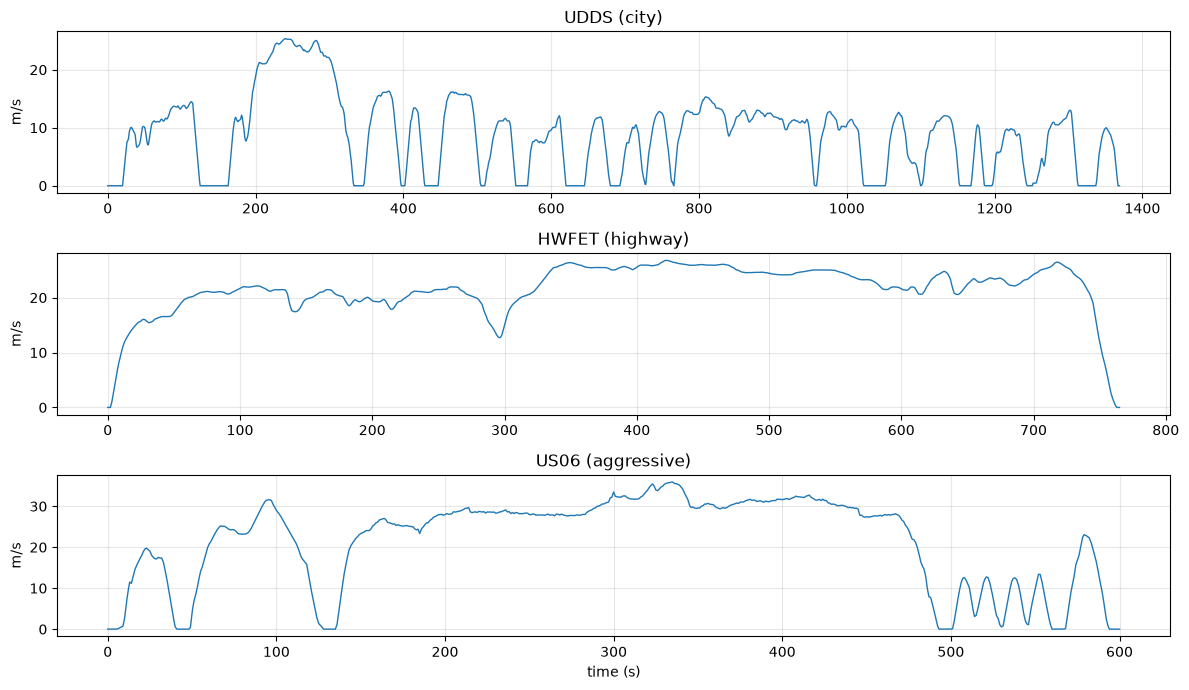

In [9]:
CYCLE_FILES = {"UDDS (city)": "uddscol.txt", "HWFET (highway)": "hwycol.txt", "US06 (aggressive)": "us06col.txt"}
cycles = {name: load_cycle(os.path.join("data", "drive_cycles", f)) for name, f in CYCLE_FILES.items()}

rows = []
for name, ref in cycles.items():
    acc = np.diff(ref) / DT
    rows.append({"cycle": name, "duration (s)": len(ref) * DT, "distance (km)": ref.sum() * DT / 1000,
                 "max speed (m/s)": ref.max(), "mean speed (m/s)": ref.mean(),
                 "max accel (m/s²)": acc.max(), "max decel (m/s²)": -acc.min(), "stopped (%)": 100 * np.mean(ref < 0.1)})
display(pd.DataFrame(rows).set_index("cycle").round(2))

fig, axes = plt.subplots(3, 1, figsize=(12, 7))
for ax, (name, ref) in zip(axes, cycles.items()):
    ax.plot(np.arange(len(ref)) * DT, ref, lw=1)
    ax.set(title=name, ylabel="m/s"); ax.grid(alpha=0.3)
axes[-1].set_xlabel("time (s)")
plt.tight_layout(); plt.show()

## 2. LSTM training data: synthetic traffic episodes

`eco_make_dataset`: 300 s episodes at the simulation step, generated as sequences of accelerate → cruise (with slow speed wobble) →
decelerate or stop → idle. Three driving styles with different speed, stop and acceleration ranges. Episodes are split
80/20 into train and validation **by episode**, so no validation window overlaps a training window.

240 episodes, 80/20 by episode -> 22272 train / 5568 validation windows


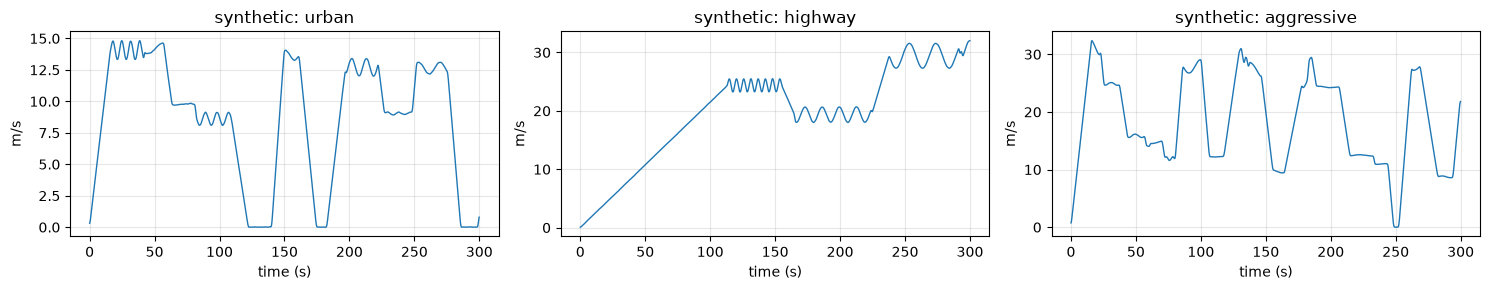

In [10]:
episodes, data = make_dataset(SEED)
(X_tr, Y_tr), (X_va, Y_va) = data["train"], data["val"]
print(f"{len(episodes)} episodes, 80/20 by episode -> {len(X_tr)} train / {len(X_va)} validation windows")

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for ax, style in zip(axes, STYLES):
    ep = next(e for s, e in episodes if s == style)
    ax.plot(np.arange(len(ep)) * DT, ep, lw=1); ax.set(title=f"synthetic: {style}", xlabel="time (s)", ylabel="m/s")
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. LSTM speed forecaster

Stacked LSTM (128 → 64, batch normalisation, dropout 0.2, dense 32 → 20). The network sees the 10 s history *relative to
the latest speed* plus the latest speed itself, and predicts the change over the next 20 steps. Predicting the change
rather than the absolute speed makes "no change" the natural starting point, so the network only has to learn what
persistence misses. Early stopping on the validation episodes restores the best epoch. Training is deterministic
for a given seed (`eco_train_forecaster`); different seeds give noticeably different LSTMs, which is why
`multi_seed_evaluation.ipynb` repeats this part with five seeds.

trained 16 epochs in 277 s; best validation epoch: 11


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           660 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 359,198 (1.37 MB)

 Trainable params: 119,604 (467.20 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 239,210 (934.42 KB)

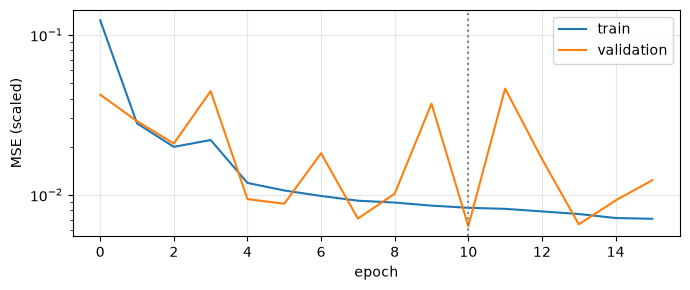

In [11]:
t0 = time.time()
model, hist = train_forecaster(data, SEED)
best = int(np.argmin(hist["val_loss"])) + 1
print(f"trained {len(hist['loss'])} epochs in {time.time() - t0:.0f} s; best validation epoch: {best}")
model.summary()

plt.figure(figsize=(7, 3))
plt.plot(hist["loss"], label="train"); plt.plot(hist["val_loss"], label="validation")
plt.axvline(best - 1, color="grey", ls=":"); plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("MSE (scaled)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

forecast_lstm = lambda X: lstm_forecast(model, X)

## 4. Forecast quality

RMSE over the 2 s horizon, against persistence and a constant-acceleration extrapolation. On the EPA cycles the forecast
at each step uses only the cycle's past.

In [12]:
rmse = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))
forecasts = {}
rows = [{"profile": "synthetic validation", "LSTM": rmse(forecast_lstm(X_va), Y_va),
         "persistence": rmse(np.repeat(X_va[:, -1:], H, axis=1), Y_va), "constant accel.": np.nan}]
for name, ref in cycles.items():
    truth = forecast_oracle(ref)
    forecasts[name] = {"persistence": forecast_persistence(ref),
                       "const. accel": forecast_const_accel(ref),
                       "LSTM": forecast_lstm(history_windows(ref, SEQ)),
                       "oracle": truth}
    rows.append({"profile": name, "LSTM": rmse(forecasts[name]["LSTM"], truth),
                 "persistence": rmse(forecasts[name]["persistence"], truth),
                 "constant accel.": rmse(forecasts[name]["const. accel"], truth)})
fc_table = pd.DataFrame(rows).set_index("profile")
display(fc_table.round(3))
print("2 s forecast RMSE in m/s (lower is better).")

,LSTM,persistence,constant accel.
profile,,,
synthetic validation,0.389,1.038,NaN
UDDS (city),0.261,0.729,0.292
HWFET (highway),0.125,0.352,0.133
US06 (aggressive),0.520,1.133,0.582


2 s forecast RMSE in m/s (lower is better).


## 5. Vehicle and controllers

The plant (`eco_ElectricVehicle`): 2,500 kg, C_d·A = 0.28 × 2.5 m², rolling coefficient 0.015, 0.36 m wheels,
9:1 gear, motor 400 Nm / 150 kW at 92 % efficiency, regen up to 200 Nm / 60 kW at 75 % (disabled below 1 m/s), friction
brakes for the rest. Energy is **net battery energy** (motoring minus recovered regen) per km driven.

| Controller | Uses the forecast | How |
|---|---|---|
| Bang-bang | no | full drive / full braking outside a ±0.5 m/s band, coast inside it |
| PID | no | kp = 2500, ki = 150 (Nm per m/s), anti-windup |
| PID + forecast | yes | same PID; if the forecast drops > 1 m/s below the current target within 0.8 s, torque is reduced by 400 Nm per m/s of drop (deceleration-only feedforward) |
| MPC + forecast | yes | 2 s horizon as 5 moves of 0.4 s, re-planned every 0.4 s; cost = tracking² + 0.001 × battery energy + smoothness |

The MPC is run with all four forecasts (persistence, constant acceleration, LSTM, oracle), and the PID feedforward with the LSTM and the oracle. All gains and weights were
set on synthetic profiles before any EPA run.

In [13]:
ev = ElectricVehicle()
display(pd.DataFrame([{"speed (m/s)": v,
                       "max accel (m/s²)": (ev.limits(v)[0] / ev.wheel_radius - 0.5 * ev.drag_coeff * ev.frontal_area * ev.rho * v * v
                                            - ev.mass * 9.81 * ev.rolling_coeff) / ev.mass,
                       "regen-only decel (m/s²)": (ev.limits(v)[1] / ev.wheel_radius) / ev.mass}
                      for v in [5, 15, 25, 35]]).set_index("speed (m/s)").round(2))
print("The drivetrain can follow every cycle: US06 peaks at 3.8 m/s² near standstill.")

,max accel (m/s²),regen-only decel (m/s²)
speed (m/s),,
5,3.85,2.00
15,3.81,1.60
25,2.15,0.96
35,1.36,0.69


The drivetrain can follow every cycle: US06 peaks at 3.8 m/s² near standstill.


## 6. Run every controller on every cycle

8 configurations × 3 cycles, run in parallel worker processes (the MPC dominates the runtime).

In [14]:
CONTROLLERS = [   # (label, controller spec, forecast name or None)
    ("Bang-bang",        ("bangbang", {}),        None),
    ("PID",              ("pid", {}),             None),
    ("PID + LSTM",       ("pid", {"kff": 400}),   "LSTM"),
    ("PID + oracle",     ("pid", {"kff": 400}),   "oracle"),
    ("MPC + persistence", ("mpc", {}),            "persistence"),
    ("MPC + const. accel", ("mpc", {}),           "const. accel"),
    ("MPC + LSTM",       ("mpc", {}),             "LSTM"),
    ("MPC + oracle",     ("mpc", {}),             "oracle"),
]

tasks, keys = [], []
for name, ref in cycles.items():
    for label, spec, fc in CONTROLLERS:
        tasks.append((spec, ref, None if fc is None else forecasts[name][fc]))
        keys.append((name, label))

t0 = time.time()
outputs = run_parallel(tasks)
print(f"{len(tasks)} simulations in {time.time() - t0:.0f} s")

runs = {k: r for k, (r, _) in zip(keys, outputs)}
res = pd.DataFrame([{"cycle": c, "controller": l, **m} for (c, l), (_, m) in zip(keys, outputs)])
res.to_csv("results/controller_results.csv", index=False)

24 simulations in 131 s


## 7. Results

Energy is compared with the plain PID on the same cycle (positive = less energy). A controller can always save energy by
following the reference more loosely, so read every energy figure together with its tracking error.

In [15]:
labels = [l for l, _, _ in CONTROLLERS]
pid_e = res[res.controller == "PID"].set_index("cycle")["Wh/km"]
res["energy vs PID (%)"] = 100 * (res["cycle"].map(pid_e) - res["Wh/km"]) / res["cycle"].map(pid_e)

for col, fmt in [("Wh/km", 1), ("energy vs PID (%)", 1), ("RMSE (m/s)", 3), ("RMS jerk (m/s³)", 2)]:
    t = res.pivot(index="controller", columns="cycle", values=col).loc[labels, list(cycles)]
    print(col); display(t.round(fmt))

Wh/km


cycle,UDDS (city),HWFET (highway),US06 (aggressive)
controller,,,
Bang-bang,157.2,179.6,237.3
PID,165.1,182.9,240.1
PID + LSTM,165.2,183.0,241.0
PID + oracle,165.2,182.9,239.8
MPC + persistence,163.6,181.7,235.0
MPC + const. accel,165.1,182.1,243.8
MPC + LSTM,165.5,182.0,247.2
MPC + oracle,163.1,181.4,232.9


energy vs PID (%)


cycle,UDDS (city),HWFET (highway),US06 (aggressive)
controller,,,
Bang-bang,4.8,1.8,1.2
PID,0.0,0.0,0.0
PID + LSTM,-0.0,-0.0,-0.4
PID + oracle,-0.1,-0.0,0.1
MPC + persistence,0.9,0.7,2.1
MPC + const. accel,0.0,0.5,-1.5
MPC + LSTM,-0.2,0.5,-3.0
MPC + oracle,1.2,0.8,3.0


RMSE (m/s)


cycle,UDDS (city),HWFET (highway),US06 (aggressive)
controller,,,
Bang-bang,0.354,0.395,0.509
PID,0.213,0.087,0.332
PID + LSTM,0.194,0.084,0.293
PID + oracle,0.189,0.084,0.290
MPC + persistence,0.421,0.181,0.557
MPC + const. accel,0.179,0.123,0.234
MPC + LSTM,0.078,0.125,0.185
MPC + oracle,0.054,0.127,0.187


RMS jerk (m/s³)


cycle,UDDS (city),HWFET (highway),US06 (aggressive)
controller,,,
Bang-bang,15.92,12.62,15.06
PID,0.39,0.15,0.74
PID + LSTM,0.56,0.22,0.91
PID + oracle,0.47,0.18,0.78
MPC + persistence,1.71,0.46,1.78
MPC + const. accel,1.80,0.60,2.47
MPC + LSTM,2.02,1.00,3.63
MPC + oracle,0.82,0.46,1.37


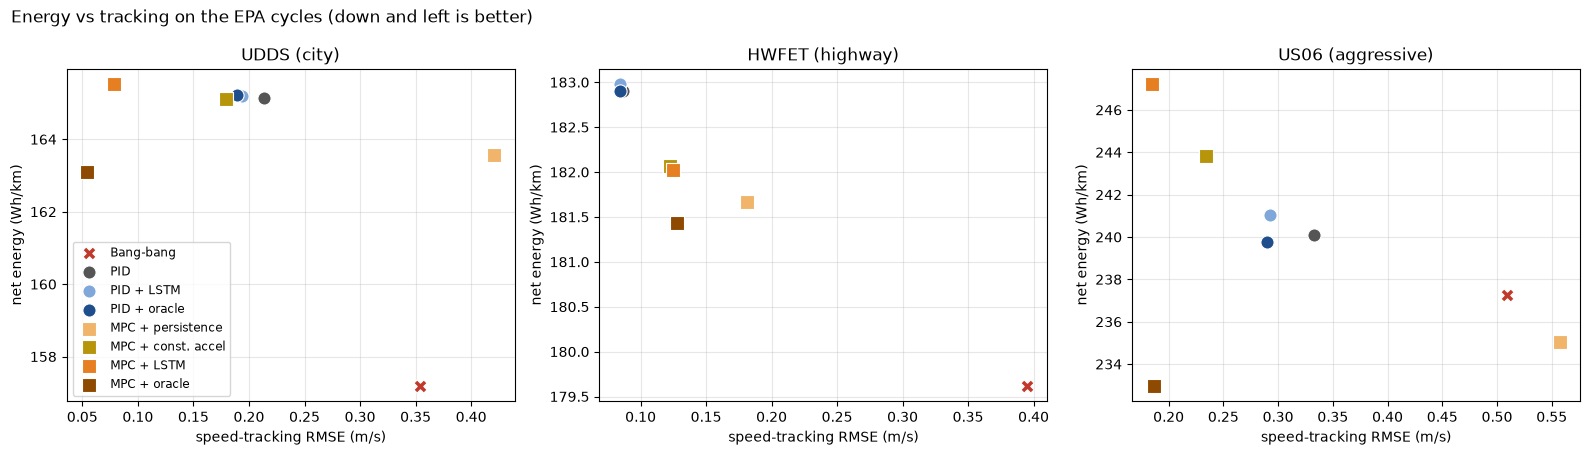

In [16]:
colours = {"Bang-bang": "#c0392b", "PID": "#555555", "PID + LSTM": "#7fa7d9", "PID + oracle": "#1f4e8c",
           "MPC + persistence": "#f0b46b", "MPC + const. accel": "#b7950b", "MPC + LSTM": "#e67e22", "MPC + oracle": "#8e4a00"}
markers = {"Bang-bang": "X", "PID": "o", "PID + LSTM": "o", "PID + oracle": "o",
           "MPC + persistence": "s", "MPC + const. accel": "s", "MPC + LSTM": "s", "MPC + oracle": "s"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, name in zip(axes, cycles):
    sub = res[res.cycle == name].set_index("controller")
    for l in labels:
        ax.scatter(sub.loc[l, "RMSE (m/s)"], sub.loc[l, "Wh/km"], s=90, color=colours[l], marker=markers[l],
                   edgecolor="white", linewidth=0.8, label=l, zorder=3)
    ax.set(title=name, xlabel="speed-tracking RMSE (m/s)", ylabel="net energy (Wh/km)")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8.5, loc="best")
fig.suptitle("Energy vs tracking on the EPA cycles (down and left is better)", x=0.01, ha="left", fontsize=12.5)
plt.tight_layout()
plt.savefig("results/controller_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

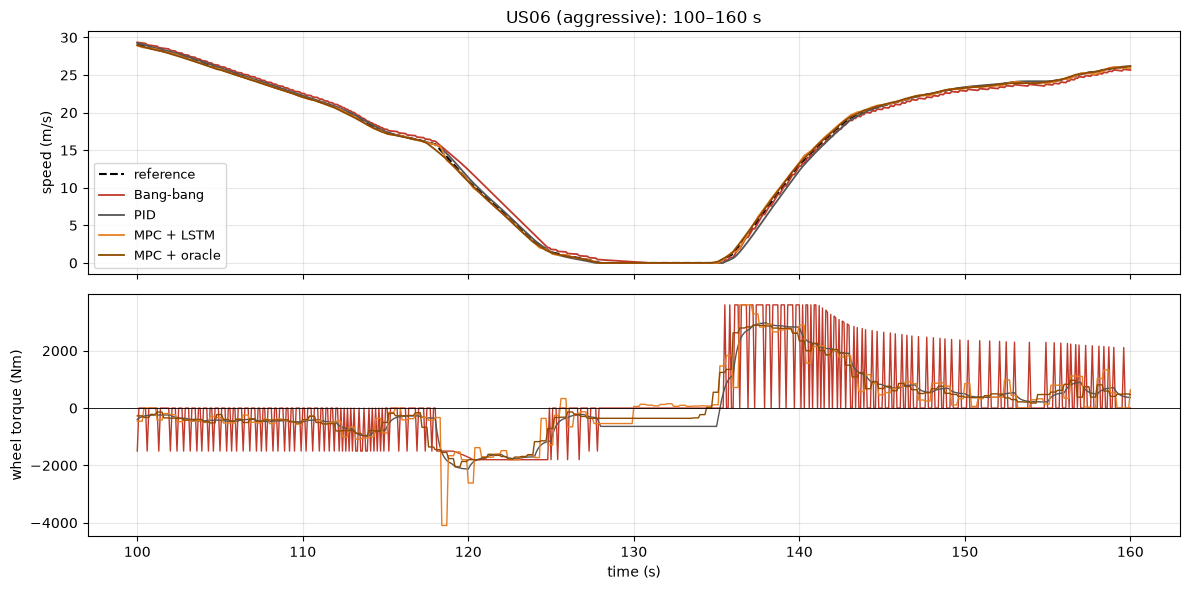

In [17]:
# Zoom: one US06 acceleration-braking event
name = "US06 (aggressive)"
ref = cycles[name]
t = np.arange(len(ref)) * DT
win = (t >= 100) & (t <= 160)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(t[win], ref[win], "k--", lw=1.5, label="reference")
for l in ["Bang-bang", "PID", "MPC + LSTM", "MPC + oracle"]:
    axes[0].plot(t[win], runs[(name, l)]["v"][win], color=colours[l], lw=1.3, label=l)
    axes[1].plot(t[win], runs[(name, l)]["T"][win], color=colours[l], lw=1.0, label=l)
axes[0].set(ylabel="speed (m/s)", title=f"{name}: 100–160 s"); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set(ylabel="wheel torque (Nm)", xlabel="time (s)"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig("results/us06_trace.png", dpi=150, bbox_inches="tight"); plt.show()

## 8. Energy–tracking trade-off of the MPC

The MPC's energy weight sets how much tracking it gives up for energy. Sweeping it, for each forecast, shows whether a
better forecast buys energy at the same tracking quality (its curve would sit lower) or mainly better tracking.

36 simulations in 284 s


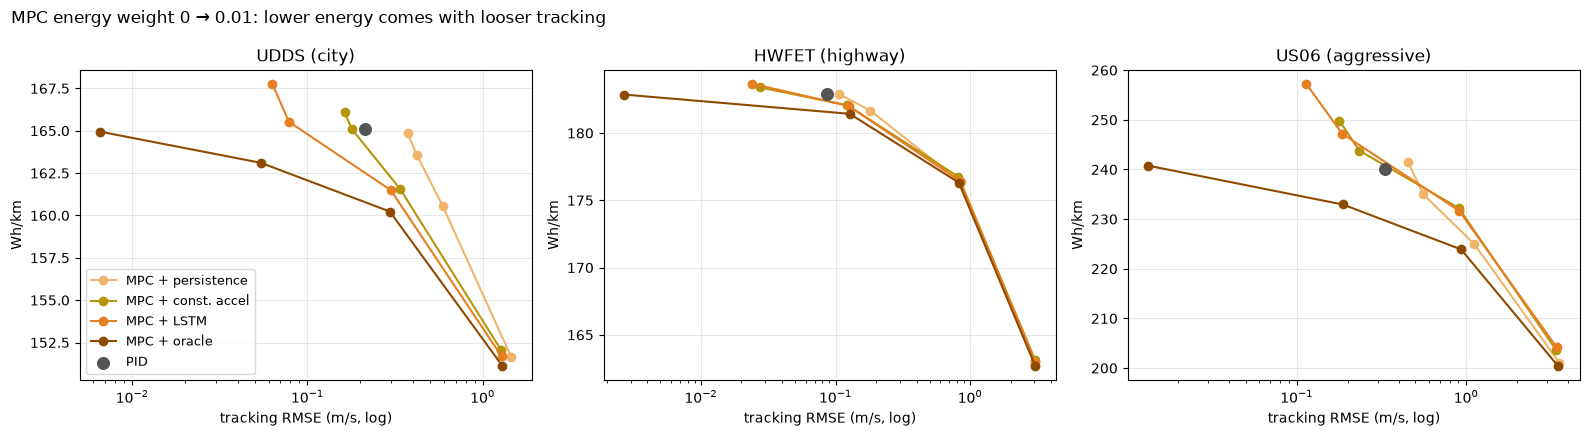

In [18]:
WEIGHTS = [0.0, 0.001, 0.003, 0.01]
sweep_tasks, sweep_keys = [], []
for name, ref in cycles.items():
    for fc in ["persistence", "const. accel", "LSTM", "oracle"]:
        for w in WEIGHTS:
            if w == 0.001:
                continue                                  # already run above
            sweep_tasks.append((("mpc", {"w_energy": w}), ref, forecasts[name][fc]))
            sweep_keys.append((name, fc, w))
t0 = time.time()
sweep_out = run_parallel(sweep_tasks)
print(f"{len(sweep_tasks)} simulations in {time.time() - t0:.0f} s")

sweep = pd.DataFrame([{"cycle": c, "forecast": f, "w_energy": w, **m} for (c, f, w), (_, m) in zip(sweep_keys, sweep_out)])
main = res[res.controller.str.startswith("MPC")].assign(forecast=lambda d: d.controller.str.replace("MPC + ", ""),
                                                          w_energy=0.001)
sweep = pd.concat([sweep, main[sweep.columns]], ignore_index=True).sort_values(["cycle", "forecast", "w_energy"])
sweep.to_csv("results/mpc_tradeoff.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, name in zip(axes, cycles):
    for fc, col in [("persistence", "#f0b46b"), ("const. accel", "#b7950b"), ("LSTM", "#e67e22"), ("oracle", "#8e4a00")]:
        s = sweep[(sweep.cycle == name) & (sweep.forecast == fc)]
        ax.plot(s["RMSE (m/s)"], s["Wh/km"], "-o", color=col, label=f"MPC + {fc}")
    p = res[(res.cycle == name) & (res.controller == "PID")]
    ax.scatter(p["RMSE (m/s)"], p["Wh/km"], color="#555555", s=70, zorder=3, label="PID")
    ax.set_xscale("log"); ax.set(title=name, xlabel="tracking RMSE (m/s, log)", ylabel="Wh/km"); ax.grid(alpha=0.3)
axes[0].legend(fontsize=9)
fig.suptitle("MPC energy weight 0 → 0.01: lower energy comes with looser tracking", x=0.01, ha="left", fontsize=12.5)
plt.tight_layout(); plt.savefig("results/mpc_tradeoff.png", dpi=150, bbox_inches="tight"); plt.show()

### Energy at equal tracking

Each MPC curve, interpolated (in log RMSE) to the tracking error of the plain PID on the same cycle: the energy each
forecast needs to track as well as PID. Empty = that MPC never tracks as tightly as PID at any weight tried.

In [19]:
rows = []
for name in cycles:
    pid = res[(res.cycle == name) & (res.controller == "PID")].iloc[0]
    row = {"cycle": name, "PID RMSE (m/s)": pid["RMSE (m/s)"], "PID Wh/km": pid["Wh/km"]}
    for fc in ["persistence", "const. accel", "LSTM", "oracle"]:
        e = energy_at_tracking(sweep[(sweep.cycle == name) & (sweep.forecast == fc)].to_dict("records"),
                                   pid["RMSE (m/s)"])
        row[f"MPC + {fc}: saving vs PID (%)"] = 100 * (pid["Wh/km"] - e) / pid["Wh/km"]
    rows.append(row)
matched = pd.DataFrame(rows).set_index("cycle")
matched.to_csv("results/energy_at_pid_tracking.csv")
display(matched.round(2))

,PID RMSE (m/s),PID Wh/km,MPC + persistence: saving vs PID (%),MPC + const. accel: saving vs PID (%),MPC + LSTM: saving vs PID (%),MPC + oracle: saving vs PID (%)
cycle,,,,,,
UDDS (city),0.21,165.13,NaN,0.61,1.59,2.63
HWFET (highway),0.09,182.91,NaN,0.29,0.28,0.73
US06 (aggressive),0.33,240.11,NaN,-0.28,-0.58,4.33


## 9. Summary

In [20]:
mpc = res.pivot(index="controller", columns="cycle", values="Wh/km")
trk = res.pivot(index="controller", columns="cycle", values="RMSE (m/s)")
for name in cycles:
    print(f"{name}:")
    print(f"  bang-bang vs PID energy: {100 * (mpc.loc['PID', name] - mpc.loc['Bang-bang', name]) / mpc.loc['PID', name]:+.1f}%"
          f"  (tracking RMSE {trk.loc['Bang-bang', name]:.2f} vs {trk.loc['PID', name]:.2f} m/s)")
    for a, b in [("MPC + const. accel", "MPC + persistence"), ("MPC + LSTM", "MPC + persistence"),
                 ("MPC + oracle", "MPC + persistence"), ("PID + LSTM", "PID")]:
        print(f"  {a} vs {b}: energy {100 * (mpc.loc[b, name] - mpc.loc[a, name]) / mpc.loc[b, name]:+.1f}%, "
              f"RMSE {trk.loc[b, name]:.3f} -> {trk.loc[a, name]:.3f} m/s")

UDDS (city):
  bang-bang vs PID energy: +4.8%  (tracking RMSE 0.35 vs 0.21 m/s)
  MPC + const. accel vs MPC + persistence: energy -0.9%, RMSE 0.421 -> 0.179 m/s
  MPC + LSTM vs MPC + persistence: energy -1.2%, RMSE 0.421 -> 0.078 m/s
  MPC + oracle vs MPC + persistence: energy +0.3%, RMSE 0.421 -> 0.054 m/s
  PID + LSTM vs PID: energy -0.0%, RMSE 0.213 -> 0.194 m/s
HWFET (highway):
  bang-bang vs PID energy: +1.8%  (tracking RMSE 0.39 vs 0.09 m/s)
  MPC + const. accel vs MPC + persistence: energy -0.2%, RMSE 0.181 -> 0.123 m/s
  MPC + LSTM vs MPC + persistence: energy -0.2%, RMSE 0.181 -> 0.125 m/s
  MPC + oracle vs MPC + persistence: energy +0.1%, RMSE 0.181 -> 0.127 m/s
  PID + LSTM vs PID: energy -0.0%, RMSE 0.087 -> 0.084 m/s
US06 (aggressive):
  bang-bang vs PID energy: +1.2%  (tracking RMSE 0.51 vs 0.33 m/s)
  MPC + const. accel vs MPC + persistence: energy -3.7%, RMSE 0.557 -> 0.234 m/s
  MPC + LSTM vs MPC + persistence: energy -5.2%, RMSE 0.557 -> 0.185 m/s
  MPC + oracle vs MP

### Reading the results

* **A perfect 2 s preview is worth a few percent, mostly in aggressive driving.** At the PID's tracking error, the MPC
  with the true future speed uses 2.6 % (UDDS), 0.7 % (HWFET) and 4.3 % (US06) less energy than the PID. Over 2 s, highway
  speed barely changes, so there is little to anticipate.
* **The LSTM recovers little of that.** Its forecast halves persistence's error, but a constant-acceleration
  extrapolation is about as accurate (better on the city and highway cycles across 5 seeds, slightly worse on US06; see
  `multi_seed_evaluation.ipynb`). At equal tracking, MPC + LSTM saves 1.0 % ± 0.8 on UDDS, 0.0 % ± 0.6 on HWFET and
  −0.9 % ± 1.7 on US06 (5 seeds).
* **Forecast smoothness matters as much as accuracy.** The LSTM forecast changes from step to step, and the MPC re-plans
  on each new one: its RMS jerk is 2–3× the oracle MPC's, and the extra acceleration costs energy.
* **The deceleration feedforward in PID does not change energy** (≤ 0.4 %), even with a perfect forecast. It tightens
  tracking slightly.
* **Bang-bang uses 1–5 % less energy than PID, but tracks 1.5–4.5× worse and its jerk is 20–80× higher.** It coasts
  inside its ±0.5 m/s band, and coasting is cheap. Energy figures without tracking and comfort next to them are
  misleading, which is why the comparisons above are made at equal tracking.
* **No forecast is not enough for MPC:** with persistence it never tracks as tightly as the PID at any weight tried.